In [1]:
# Cell 1 — Imports and configuration

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ---- Configuration ----
# Paths are relative to the notebooks/ folder, so we go up one level with ".."
TRAIN_DIR = os.path.join("..", "data", "Training")
TEST_DIR  = os.path.join("..", "data", "Testing")

IMG_SIZE   = (224, 224)   # VGG16 expects 224x224
BATCH_SIZE = 32
NUM_CLASSES = 4
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

print("TensorFlow version:", tf.__version__)
print("Training dir exists:", os.path.isdir(TRAIN_DIR))
print("Testing dir exists :", os.path.isdir(TEST_DIR))
print("GPU available      :", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
Training dir exists: True
Testing dir exists : True
GPU available      : []


In [2]:
# Cell 2 — Count images per class

def count_images(base_dir):
    counts = {}
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        # Count only image files
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        counts[class_name] = len(files)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("TRAINING set:")
for cls, n in train_counts.items():
    print(f"  {cls:12s}: {n}")
print(f"  {'TOTAL':12s}: {sum(train_counts.values())}")

print("\nTESTING set:")
for cls, n in test_counts.items():
    print(f"  {cls:12s}: {n}")
print(f"  {'TOTAL':12s}: {sum(test_counts.values())}")

TRAINING set:
  glioma      : 1400
  meningioma  : 1400
  notumor     : 1400
  pituitary   : 1400
  TOTAL       : 5600

TESTING set:
  glioma      : 400
  meningioma  : 400
  notumor     : 400
  pituitary   : 400
  TOTAL       : 1600


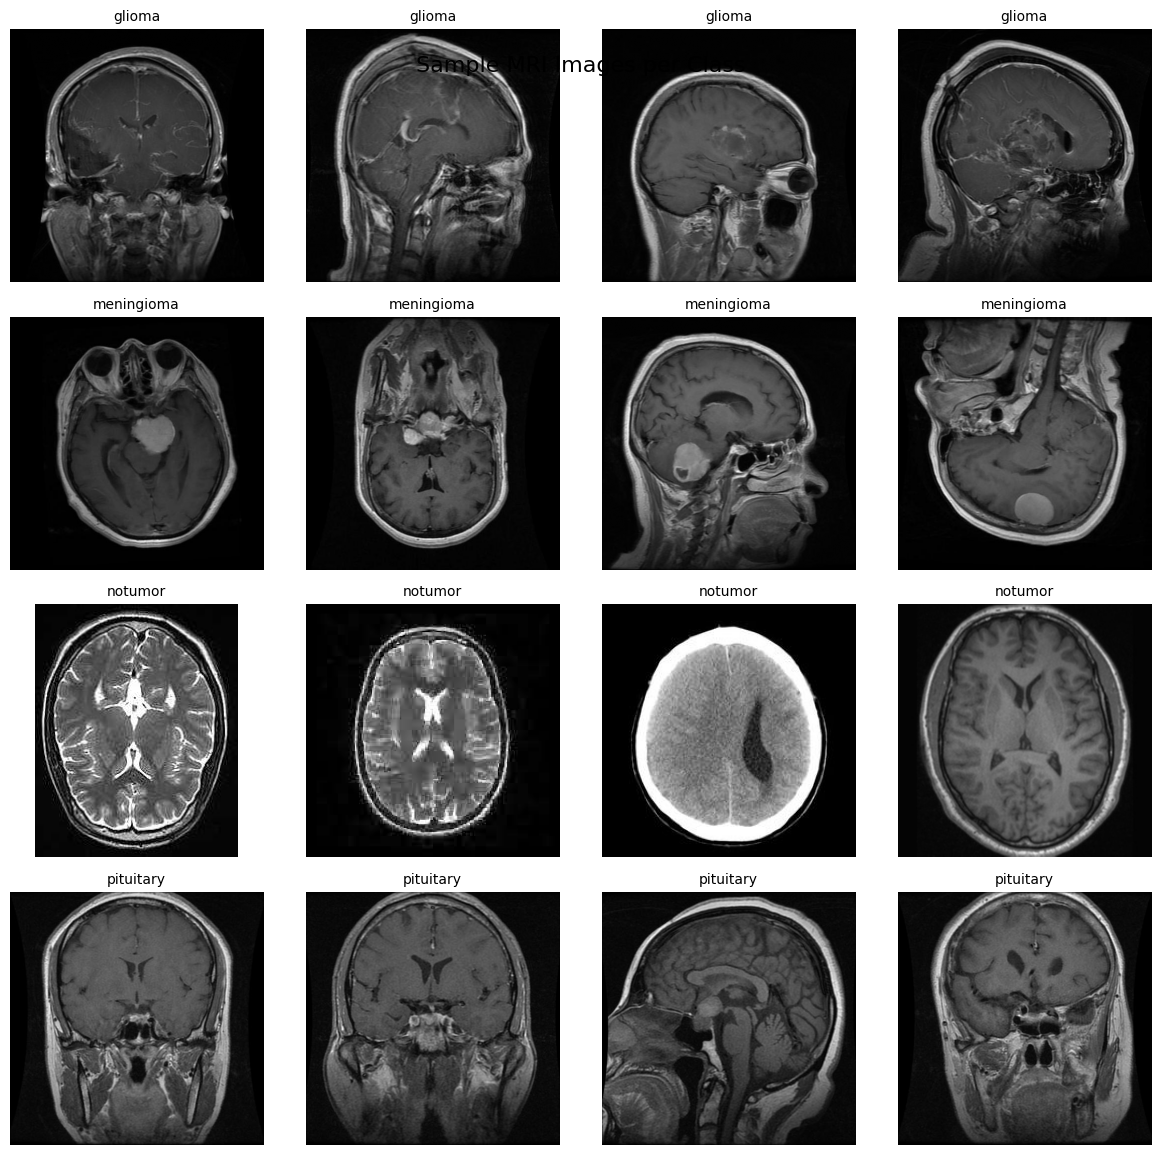

In [3]:
# Cell 3 — Visualize sample images from each class

import matplotlib.image as mpimg

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 12))

for row, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_DIR, class_name)
    files = [f for f in os.listdir(class_path)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    sample_files = files[:4]  # first 4 images from this class

    for col, fname in enumerate(sample_files):
        img = mpimg.imread(os.path.join(class_path, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(class_name, fontsize=12)
        axes[row, col].set_title(class_name, fontsize=10)

plt.suptitle("Sample MRI Images per Class", fontsize=16, y=0.92)
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — Data generators with augmentation

# Training generator: augmentation + 15% validation split
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.15
)

# Test generator: only preprocessing, NO augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Training subset (85% of training data)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    subset="training",
    shuffle=True,
    seed=42
)

# Validation subset (15% of training data)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    subset="validation",
    shuffle=True,
    seed=42
)

# Test set (kept fully separate, not shuffled so labels line up later)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [5]:
# Cell 5 — Build the VGG16 transfer-learning model

# Load VGG16 base, pretrained on ImageNet, WITHOUT its top classification layer
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the convolutional base — keep ImageNet features, don't retrain them
base_model.trainable = False

# Build our own classification head on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)                              # reduce overfitting
predictions = Dense(NUM_CLASSES, activation="softmax")(x)   # 4 classes

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



58889256/58889256 [==============================] - 10s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                           

In [6]:
# Cell 6 — Train the model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining complete.")

Epoch 1/15


149/149 [==============================] - 1068s 7s/step - loss: 2.3588 - accuracy: 0.7210 - val_loss: 0.6334 - val_accuracy: 0.8107 - lr: 1.0000e-04
Epoch 2/15
149/149 [==============================] - 1050s 7s/step - loss: 0.6409 - accuracy: 0.7914 - val_loss: 0.4247 - val_accuracy: 0.8643 - lr: 1.0000e-04
Epoch 3/15
149/149 [==============================] - 1042s 7s/step - loss: 0.4834 - accuracy: 0.8330 - val_loss: 0.3288 - val_accuracy: 0.8714 - lr: 1.0000e-04
Epoch 4/15
149/149 [==============================] - 1041s 7s/step - loss: 0.4286 - accuracy: 0.8525 - val_loss: 0.3568 - val_accuracy: 0.8810 - lr: 1.0000e-04
Epoch 5/15
149/149 [==============================] - 1047s 7s/step - loss: 0.3847 - accuracy: 0.8542 - val_loss: 0.3107 - val_accuracy: 0.8798 - lr: 1.0000e-04
Epoch 6/15
149/149 [==============================] - 1079s 7s/step - loss: 0.3462 - accuracy: 0.8782 - val_loss: 0.3288 - val_accuracy: 0.8857 - lr: 1.0000e-04
Epoch 7/15
149/149 [============

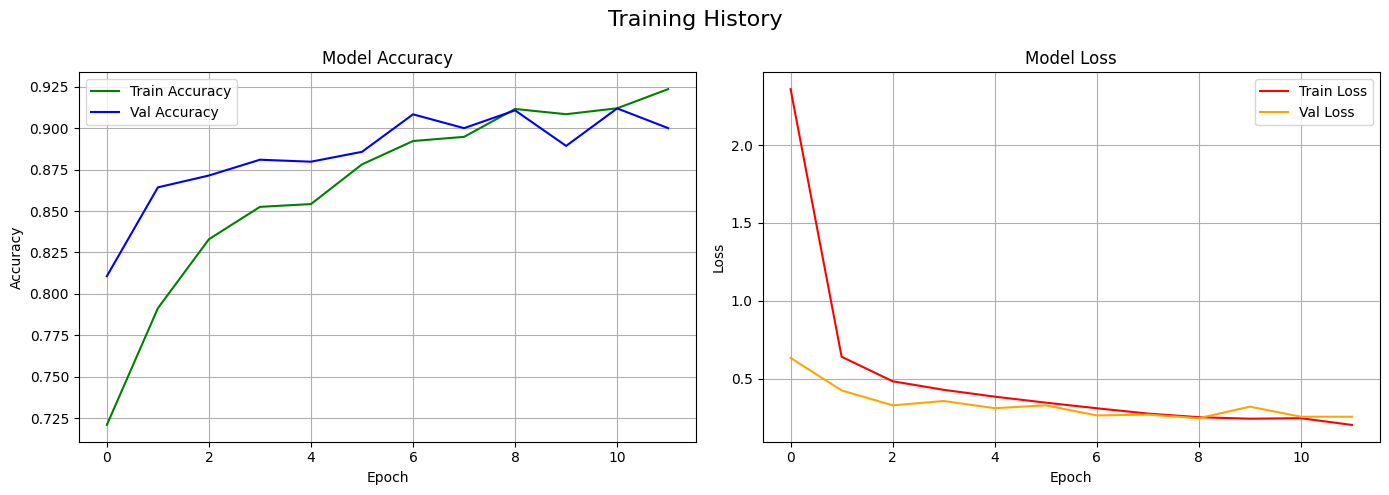

In [7]:
# Cell 7 — Plot training history (accuracy & loss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy", color="green")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy", color="blue")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history["loss"], label="Train Loss", color="red")
axes[1].plot(history.history["val_loss"], label="Val Loss", color="orange")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training History", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 — Generate predictions on the test set

# Predicted probabilities for all 1600 test images (4 values per image)
pred_probs = model.predict(test_generator, verbose=1)

# Convert probabilities to predicted class index (0–3)
y_pred = np.argmax(pred_probs, axis=1)

# True class indices, in the same order (test_generator has shuffle=False)
y_true = test_generator.classes

print("\nPrediction array shape:", pred_probs.shape)   # (1600, 4)
print("Predicted labels shape :", y_pred.shape)         # (1600,)
print("True labels shape      :", y_true.shape)         # (1600,)

# Quick overall accuracy
test_accuracy = np.mean(y_pred == y_true)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

50/50 [==============================] - 292s 6s/step

Prediction array shape: (1600, 4)
Predicted labels shape : (1600,)
True labels shape      : (1600,)

Test Accuracy: 0.8681


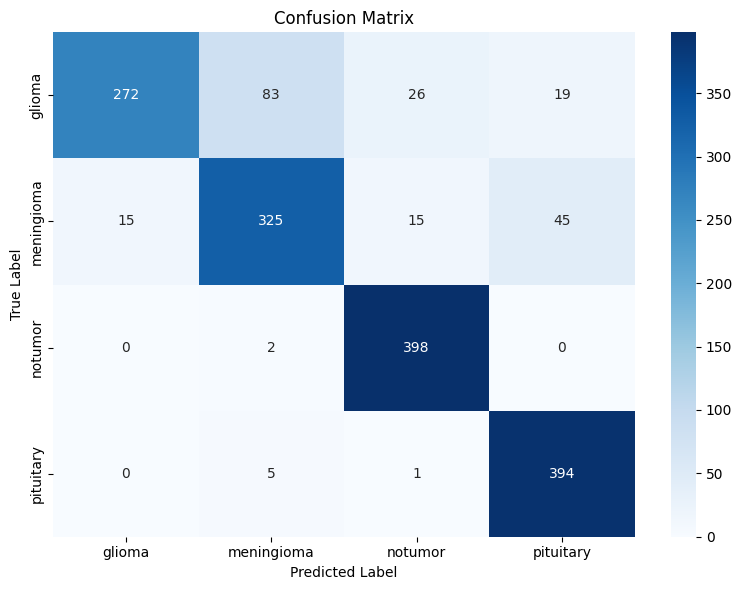

Per-class results (out of 400 each):
  glioma      : 272/400 correct
  meningioma  : 325/400 correct
  notumor     : 398/400 correct
  pituitary   : 394/400 correct


In [9]:
# Cell 9 — Confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Print per-class correct counts for quick reading
print("Per-class results (out of 400 each):")
for i, cls in enumerate(CLASS_NAMES):
    correct = cm[i, i]
    print(f"  {cls:12s}: {correct}/400 correct")

In [10]:
# Cell 10 — Classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=2
)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      glioma       0.95      0.68      0.79       400
  meningioma       0.78      0.81      0.80       400
     notumor       0.90      0.99      0.95       400
   pituitary       0.86      0.98      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.86      1600
weighted avg       0.87      0.87      0.86      1600



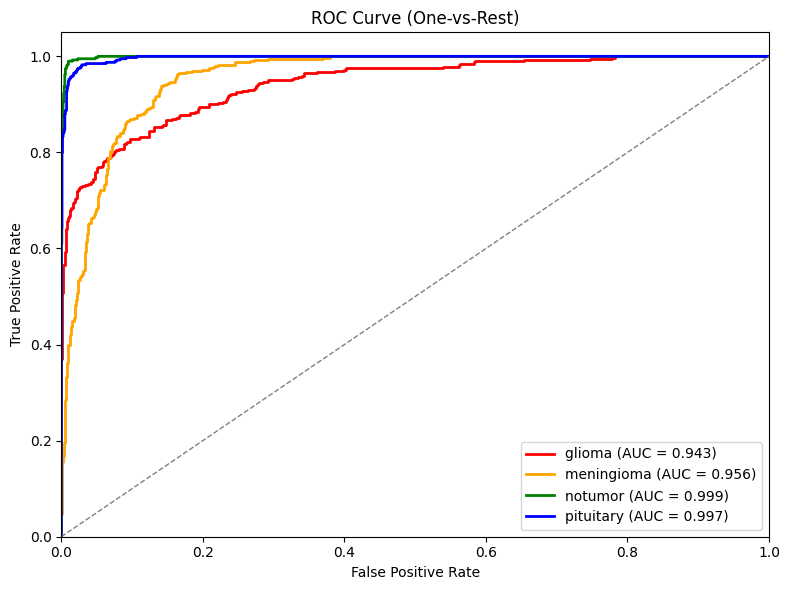

In [11]:
# Cell 11 — Multi-class ROC curves (one-vs-rest)

# Binarize the true labels into one-hot form: shape (1600, 4)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
colors = ["red", "orange", "green", "blue"]

for i, cls in enumerate(CLASS_NAMES):
    # ROC for class i vs all others, using the predicted probability for class i
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{cls} (AUC = {roc_auc:.3f})")

# Diagonal reference line (random guessing)
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
# Cell 12 — Save the trained model

import os

# Make sure the models folder exists (one level up from notebooks/)
os.makedirs(os.path.join("..", "models"), exist_ok=True)

model_path = os.path.join("..", "models", "brain_tumor_vgg16.keras")
model.save(model_path)

print("Model saved to:", model_path)
print("File size:", round(os.path.getsize(model_path) / (1024*1024), 1), "MB")

# Also save the class names so the app knows label order
import json
labels_path = os.path.join("..", "models", "class_names.json")
with open(labels_path, "w") as f:
    json.dump(CLASS_NAMES, f)
print("Class names saved to:", labels_path)

Model saved to: ..\models\brain_tumor_vgg16.keras
File size: 129.7 MB
Class names saved to: ..\models\class_names.json
